# PRICING STRATEGY OPTIMIZATION SYSTEM

This project recommends optimal pricing strategies using machine learning on supermarket sales data.

## Problem Statement

A retail company sells a wide range of products both online and offline. Setting the right price for each product is critical: pricing too high may reduce sales, while pricing too low may erode profits. Traditionally, pricing decisions rely on manual analysis, competitor benchmarking, or static rules, which often fail to capture dynamic market conditions, demand fluctuations, and customer behavior.

To address this challenge, the organization aims to develop an **AI-powered Pricing Strategy Optimization System** that uses historical and real-time data to recommend optimal pricing strategies for products.

## Objectives

- Predict demand at different price points for each product
- Recommend optimal pricing to maximize revenue or profit
- Adapt pricing strategies dynamically based on changing market conditions
- Provide actionable insights for sales and marketing teams

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('All libraries imported successfully!')

All libraries imported successfully!


## Dataset Description

The dataset contains Supermarket Sales data from Kaggle (https://www.kaggle.com/datasets/camnugent/supermarket-sales) including:
- Unit Price and Quantity Sold
- Product Category and Branch information
- Customer Type, Gender, and Reward Points
- Tax and Total Transaction Value

These features are used to model pricing behavior and predict optimal price points.

In [3]:
# Load dataset
df = pd.read_csv('sales.csv')

print(f'Dataset Shape  : {df.shape}')
print(f'Total Columns  : {df.shape[1]}')
print(f'Total Records  : {df.shape[0]:,}')
print(f'Missing Values : {df.isnull().sum().sum()}')
print()
df.head(10)

Dataset Shape  : (1000, 12)
Total Columns  : 12
Total Records  : 1,000
Missing Values : 0



,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1
3,4,A,Chicago,Normal,Male,Detergent,Household,7.80,5,2.73,41.73,0
4,5,B,Los Angeles,Member,Female,Orange Juice,Beverages,3.50,7,1.72,26.22,2
5,6,A,Chicago,Normal,Male,Shampoo,Stationery,11.24,9,7.08,108.24,0
6,7,A,Chicago,Normal,Male,Shampoo,Personal Care,10.71,1,0.75,11.46,0
7,8,B,Los Angeles,Normal,Female,Shampoo,Household,18.23,9,11.48,175.55,0
8,9,A,Chicago,Member,Female,Apple,Fruits,14.15,20,19.81,302.81,30
9,10,B,Los Angeles,Member,Male,Shampoo,Fruits,18.42,19,24.50,374.48,37


In [4]:
print('='*55)
print(' DATASET INFO')
print('='*55)
df.info()
print()
print('='*55)
print(' STATISTICAL SUMMARY')
print('='*55)
df.describe().round(2)

 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           1000 non-null   int64  
 1   branch            1000 non-null   object 
 2   city              1000 non-null   object 
 3   customer_type     1000 non-null   object 
 4   gender            1000 non-null   object 
 5   product_name      1000 non-null   object 
 6   product_category  1000 non-null   object 
 7   unit_price        1000 non-null   float64
 8   quantity          1000 non-null   int64  
 9   tax               1000 non-null   float64
 10  total_price       1000 non-null   float64
 11  reward_points     1000 non-null   int64  
dtypes: float64(3), int64(3), object(6)
memory usage: 93.9+ KB

 STATISTICAL SUMMARY


,sale_id,unit_price,quantity,tax,total_price,reward_points
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,500.50,10.84,10.34,7.76,118.58,6.06
std,288.82,5.78,6.03,6.54,99.94,9.35
min,1.00,1.02,1.00,0.08,1.21,0.00
25%,250.75,5.87,5.00,2.51,38.38,0.00
50%,500.50,10.61,10.00,5.87,89.70,0.00
75%,750.25,15.88,16.00,11.52,176.07,10.00
max,1000.00,20.98,20.00,28.39,433.99,43.00


## Exploratory Data Analysis (EDA)

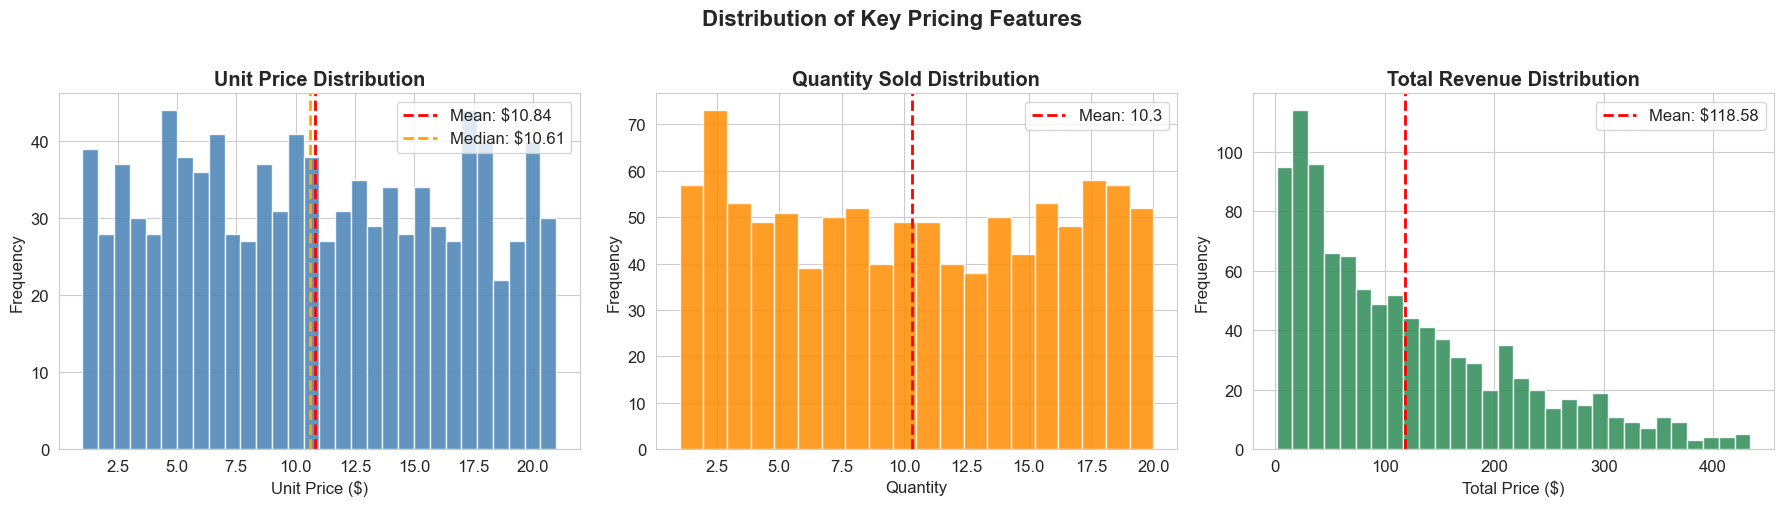

In [5]:
# Distribution of Key Pricing Features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Key Pricing Features', fontsize=16, fontweight='bold', y=1.01)

axes[0].hist(df['unit_price'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['unit_price'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: ${df["unit_price"].mean():.2f}')
axes[0].axvline(df['unit_price'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: ${df["unit_price"].median():.2f}')
axes[0].set_title('Unit Price Distribution', fontweight='bold')
axes[0].set_xlabel('Unit Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['quantity'], bins=20, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(df['quantity'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {df["quantity"].mean():.1f}')
axes[1].set_title('Quantity Sold Distribution', fontweight='bold')
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].hist(df['total_price'], bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].axvline(df['total_price'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: ${df["total_price"].mean():.2f}')
axes[2].set_title('Total Revenue Distribution', fontweight='bold')
axes[2].set_xlabel('Total Price ($)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

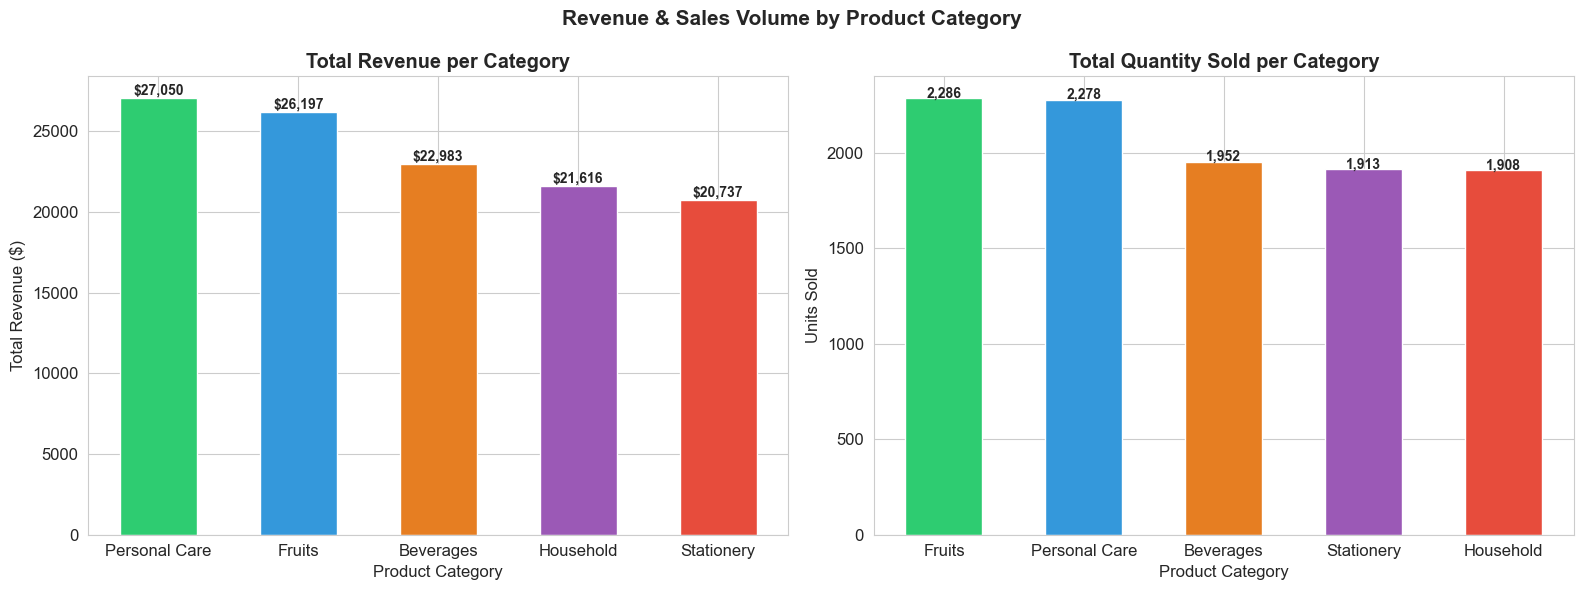

In [6]:
# Revenue & Sales Volume by Product Category
cat_revenue = df.groupby('product_category')['total_price'].sum().sort_values(ascending=False)
cat_qty     = df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue & Sales Volume by Product Category', fontsize=15, fontweight='bold')

colors = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6', '#e74c3c']

bars1 = axes[0].bar(cat_revenue.index, cat_revenue.values, color=colors, edgecolor='white', width=0.55)
axes[0].set_title('Total Revenue per Category', fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Revenue ($)')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(cat_qty.index, cat_qty.values, color=colors, edgecolor='white', width=0.55)
axes[1].set_title('Total Quantity Sold per Category', fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Units Sold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{bar.get_height():,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

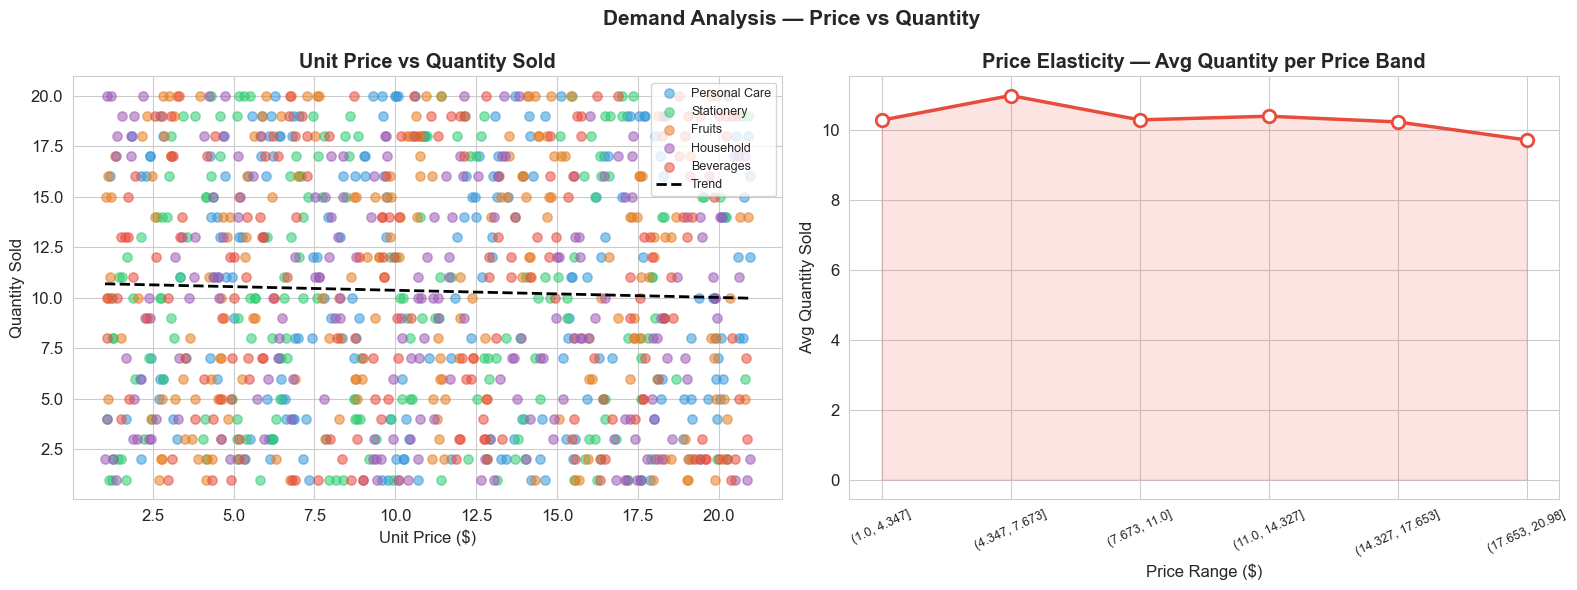

In [7]:
# Demand Analysis — Price vs Quantity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Demand Analysis — Price vs Quantity', fontsize=15, fontweight='bold')

cats = df['product_category'].unique()
cat_colors = {'Personal Care': '#3498db', 'Stationery': '#2ecc71',
              'Fruits': '#e67e22', 'Household': '#9b59b6', 'Beverages': '#e74c3c'}

for cat in cats:
    subset = df[df['product_category'] == cat]
    axes[0].scatter(subset['unit_price'], subset['quantity'],
                    alpha=0.55, label=cat, color=cat_colors.get(cat, '#999'), s=45)

z = np.polyfit(df['unit_price'], df['quantity'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['unit_price'].min(), df['unit_price'].max(), 100)
axes[0].plot(x_line, p(x_line), 'k--', linewidth=2, label='Trend')
axes[0].set_title('Unit Price vs Quantity Sold', fontweight='bold')
axes[0].set_xlabel('Unit Price ($)')
axes[0].set_ylabel('Quantity Sold')
axes[0].legend(fontsize=9)

df['price_bin'] = pd.cut(df['unit_price'], bins=6)
elasticity = df.groupby('price_bin', observed=True)['quantity'].mean()
axes[1].plot(range(len(elasticity)), elasticity.values, 'o-',
             color='#e74c3c', linewidth=2.5, markersize=9, markerfacecolor='white',
             markeredgewidth=2)
axes[1].fill_between(range(len(elasticity)), elasticity.values, alpha=0.15, color='#e74c3c')
axes[1].set_xticks(range(len(elasticity)))
axes[1].set_xticklabels([str(b) for b in elasticity.index], rotation=25, fontsize=9)
axes[1].set_title('Price Elasticity — Avg Quantity per Price Band', fontweight='bold')
axes[1].set_xlabel('Price Range ($)')
axes[1].set_ylabel('Avg Quantity Sold')

plt.tight_layout()
plt.savefig('demand_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Seasonal Trends Analysis
# Check what date-related columns exist
print("Columns:", df.columns.tolist())

Columns: ['sale_id', 'branch', 'city', 'customer_type', 'gender', 'product_name', 'product_category', 'unit_price', 'quantity', 'tax', 'total_price', 'reward_points', 'price_bin']


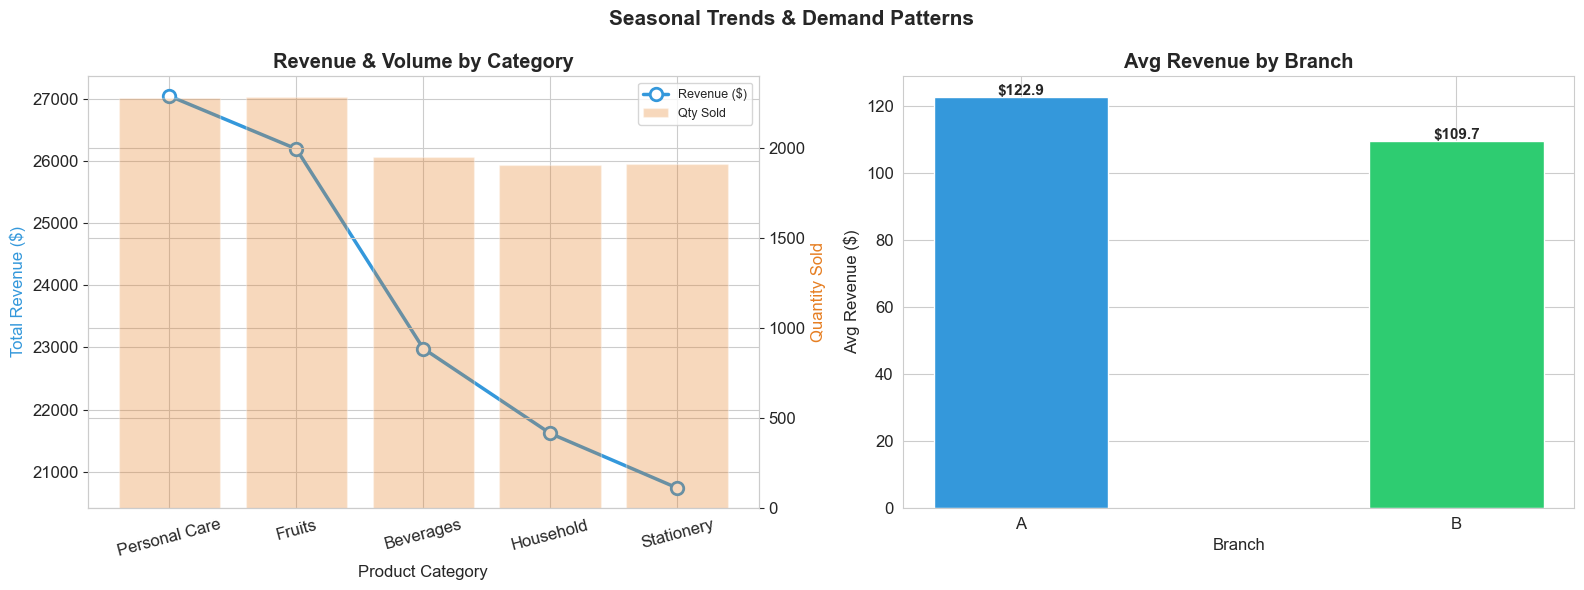

In [32]:
# Seasonal Trends Analysis (using available columns since no date column exists)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Seasonal Trends & Demand Patterns', fontsize=15, fontweight='bold')

# Revenue by category (demand spread across product lines)
cat_rev = df.groupby('product_category')['total_price'].sum().sort_values(ascending=False)
cat_qty = df.groupby('product_category')['quantity'].sum()

axes[0].plot(cat_rev.index, cat_rev.values, 'o-', color='#3498db',
             linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2, label='Revenue ($)')
ax2 = axes[0].twinx()
ax2.bar(cat_rev.index, cat_qty[cat_rev.index].values, alpha=0.3, color='#e67e22', label='Qty Sold')
ax2.set_ylabel('Quantity Sold', color='#e67e22')
axes[0].set_title('Revenue & Volume by Category', fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Revenue ($)', color='#3498db')
axes[0].tick_params(axis='x', rotation=15)
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# Avg revenue by branch
branch_avg = df.groupby('branch')['total_price'].mean()
bar_colors = ['#3498db', '#2ecc71', '#e67e22']
bars = axes[1].bar(branch_avg.index, branch_avg.values,
                   color=bar_colors[:len(branch_avg)], edgecolor='white', width=0.4)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${bar.get_height():.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Avg Revenue by Branch', fontweight='bold')
axes[1].set_xlabel('Branch')
axes[1].set_ylabel('Avg Revenue ($)')

plt.tight_layout()
plt.savefig('seasonal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

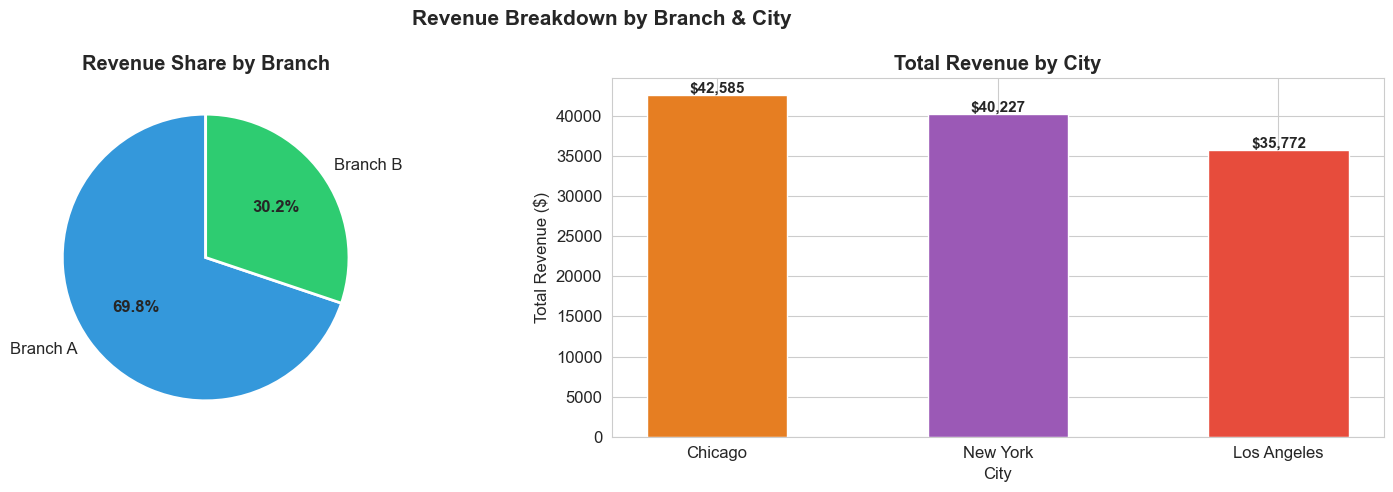

In [9]:
# Revenue Breakdown by Branch & City
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Revenue Breakdown by Branch & City', fontsize=15, fontweight='bold')

branch_rev = df.groupby('branch')['total_price'].sum()
city_rev   = df.groupby('city')['total_price'].sum().sort_values(ascending=False)

wedges, texts, autotexts = axes[0].pie(
    branch_rev.values, labels=[f'Branch {b}' for b in branch_rev.index],
    autopct='%1.1f%%', colors=['#3498db', '#2ecc71'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Revenue Share by Branch', fontweight='bold')

bars = axes[1].bar(city_rev.index, city_rev.values,
                   color=['#e67e22', '#9b59b6', '#e74c3c'], edgecolor='white', width=0.5)
axes[1].set_title('Total Revenue by City', fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Revenue ($)')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'${bar.get_height():,.0f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('branch_city_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

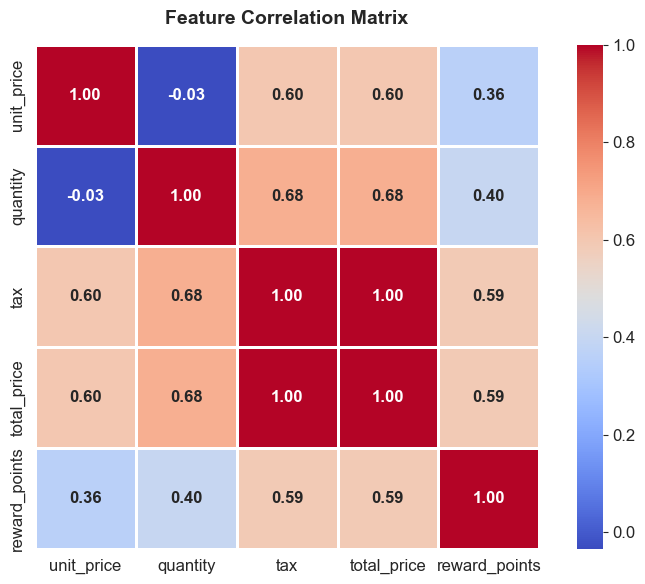

In [10]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df[['unit_price', 'quantity', 'tax', 'total_price', 'reward_points']]
corr = numeric_cols.corr()

sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.8, square=True,
    annot_kws={'size': 12, 'weight': 'bold'}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Preprocessing

- Encoded categorical variables (branch, city, customer_type, gender, product_category)
- Engineered new features: revenue_per_unit, price_band, high_value_customer
- Defined target as unit_price — the price we want to optimize
- Split data into training and test sets (80/20)

In [11]:
# Feature Engineering
df_model = df.copy()

df_model['revenue_per_unit']    = df_model['total_price'] / df_model['quantity']
df_model['price_times_qty']     = df_model['unit_price'] * df_model['quantity']
df_model['high_value_customer'] = (df_model['reward_points'] > 0).astype(int)
df_model['price_band']          = pd.cut(
    df_model['unit_price'], bins=4,
    labels=['Budget', 'Mid', 'Premium', 'Luxury']
)

le = LabelEncoder()
cat_cols = ['branch', 'city', 'customer_type', 'gender', 'product_category', 'product_name', 'price_band']
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

print('Feature Engineering Complete')
print(f'  New features: revenue_per_unit, price_times_qty, high_value_customer, price_band')
print(f'  Encoded     : {cat_cols}')
df_model[['unit_price', 'quantity', 'revenue_per_unit', 'price_times_qty', 'high_value_customer']].head()

Feature Engineering Complete
  New features: revenue_per_unit, price_times_qty, high_value_customer, price_band
  Encoded     : ['branch', 'city', 'customer_type', 'gender', 'product_category', 'product_name', 'price_band']


,unit_price,quantity,revenue_per_unit,price_times_qty,high_value_customer
0,5.50,3,5.886667,16.5,1
1,2.75,10,2.943000,27.5,0
2,1.20,15,1.284000,18.0,1
3,7.80,5,8.346000,39.0,0
4,3.50,7,3.745714,24.5,1


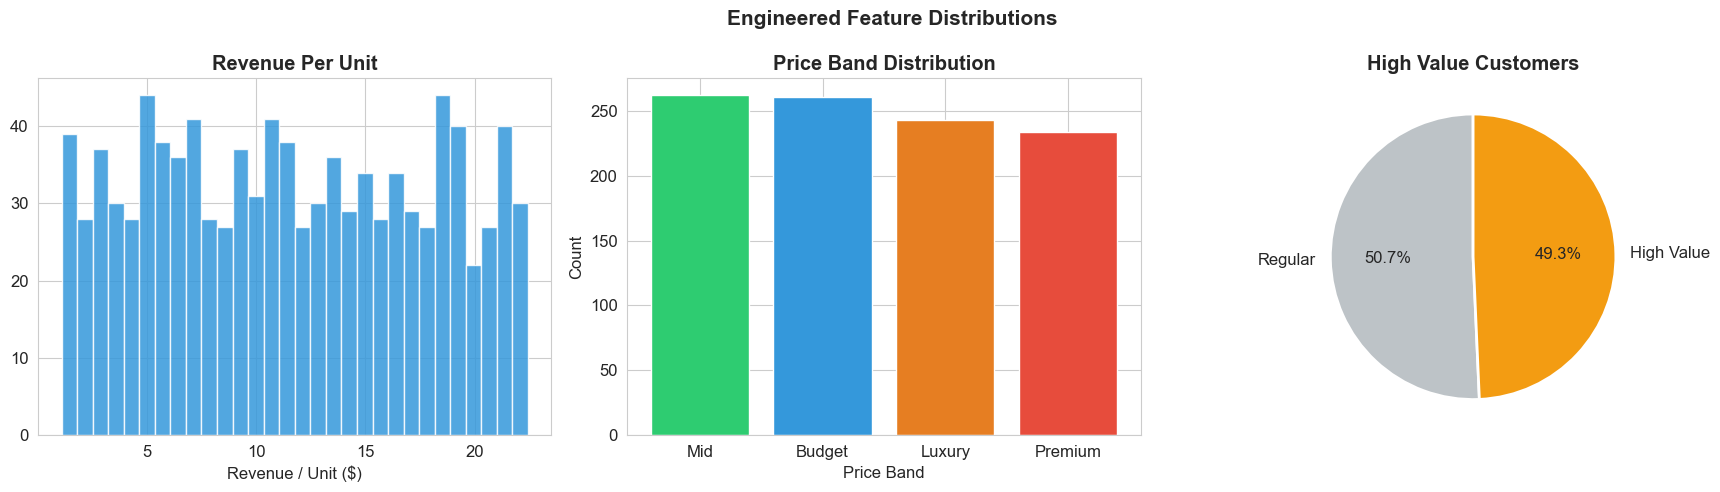

In [12]:
# Engineered Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Engineered Feature Distributions', fontsize=15, fontweight='bold')

axes[0].hist(df_model['revenue_per_unit'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Revenue Per Unit', fontweight='bold')
axes[0].set_xlabel('Revenue / Unit ($)')

price_band_counts = df_model['price_band'].value_counts()
axes[1].bar(price_band_counts.index.astype(str), price_band_counts.values,
            color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'], edgecolor='white')
axes[1].set_title('Price Band Distribution', fontweight='bold')
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Count')

hvc = df_model['high_value_customer'].value_counts()
axes[2].pie(hvc.values, labels=['Regular', 'High Value'],
            autopct='%1.1f%%', colors=['#bdc3c7', '#f39c12'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[2].set_title('High Value Customers', fontweight='bold')

plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Define Features & Target
feature_cols = [
    'quantity', 'tax', 'total_price', 'reward_points',
    'revenue_per_unit', 'price_times_qty', 'high_value_customer',
    'branch_enc', 'city_enc', 'customer_type_enc',
    'gender_enc', 'product_category_enc', 'product_name_enc'
]

X = df_model[feature_cols]
y = df_model['unit_price']  # TARGET: Predict optimal unit price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training Set : {X_train.shape[0]} samples')
print(f'Test Set     : {X_test.shape[0]} samples')
print(f'Features     : {X_train.shape[1]}')
print(f'Target       : unit_price  |  range ${y.min():.2f} — ${y.max():.2f}')

Training Set : 800 samples
Test Set     : 200 samples
Features     : 13
Target       : unit_price  |  range $1.02 — $20.98


## Model Building

We implemented a tiered modeling approach to balance interpretability and predictive power:

* Linear Regression: Serves as a baseline model to capture linear price relationships.

* Random Forest Regressor: Captures non-linear interactions and provides robust feature importance.

* Gradient Boosting Regressor: Minimizes residual errors sequentially for maximum accuracy.

* Evaluation Strategy: 5-Fold Cross-Validation was applied to prevent overfitting and ensure the model generalizes to new data.

Note: Deep learning is not used as per tool restrictions.

In [14]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_r2   = r2_score(y_test, lr_pred)

print('Linear Regression:')
print(f'  RMSE : {lr_rmse:.4f}')
print(f'  MAE  : {lr_mae:.4f}')
print(f'  R²   : {lr_r2:.4f}')


Linear Regression:
  RMSE : 0.0006
  MAE  : 0.0004
  R²   : 1.0000


In [15]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print('Random Forest Regressor:')
print(f'  RMSE : {rf_rmse:.4f}')
print(f'  MAE  : {rf_mae:.4f}')
print(f'  R²   : {rf_r2:.4f}')

Random Forest Regressor:
  RMSE : 0.0206
  MAE  : 0.0156
  R²   : 1.0000


In [16]:
# Gradient Boosting Regressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_r2   = r2_score(y_test, gb_pred)

print('Gradient Boosting Regressor:')
print(f'  RMSE : {gb_rmse:.4f}')
print(f'  MAE  : {gb_mae:.4f}')
print(f'  R²   : {gb_r2:.4f}')

Gradient Boosting Regressor:
  RMSE : 0.0470
  MAE  : 0.0345
  R²   : 0.9999


In [17]:
# Cross-Validation (5-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=kf, scoring='r2')
rf_cv = cross_val_score(rf, X_train,        y_train, cv=kf, scoring='r2')
gb_cv = cross_val_score(gb, X_train,        y_train, cv=kf, scoring='r2')

print('Cross-Validation R² Scores (5-Fold):')
print(f'  Linear Regression  : {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print(f'  Random Forest      : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')
print(f'  Gradient Boosting  : {gb_cv.mean():.4f} ± {gb_cv.std():.4f}')

Cross-Validation R² Scores (5-Fold):
  Linear Regression  : 1.0000 ± 0.0000
  Random Forest      : 1.0000 ± 0.0000
  Gradient Boosting  : 0.9999 ± 0.0000


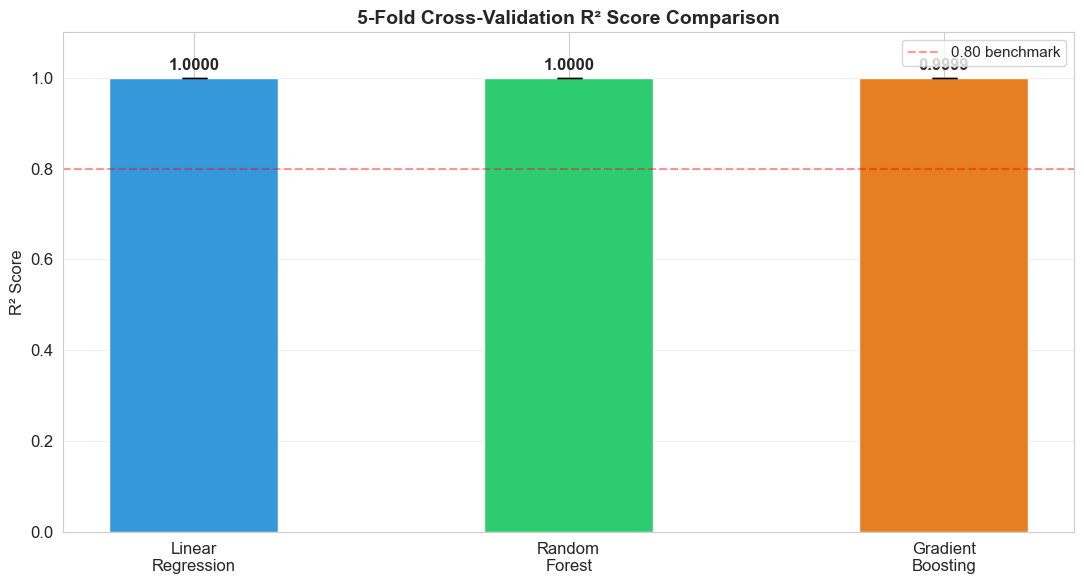

In [18]:
# CV Score Comparison Plot
fig, ax = plt.subplots(figsize=(11, 6))

model_names = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting']
cv_means    = [lr_cv.mean(), rf_cv.mean(), gb_cv.mean()]
cv_stds     = [lr_cv.std(),  rf_cv.std(),  gb_cv.std()]
colors      = ['#3498db', '#2ecc71', '#e67e22']

bars = ax.bar(model_names, cv_means, yerr=cv_stds, color=colors, capsize=9,
              edgecolor='white', width=0.45,
              error_kw={'linewidth': 2, 'color': 'black'})

for bar, mean in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylim(0, 1.1)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation R² Score Comparison', fontsize=14, fontweight='bold')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.4, label='0.80 benchmark')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Evaluation

Models were evaluated using:
- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² Score
- Actual vs Predicted plots
- Residual Analysis
- 5-Fold Cross-Validation

In [19]:
# Performance Summary Table
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE' : [lr_rmse, rf_rmse, gb_rmse],
    'MAE'  : [lr_mae,  rf_mae,  gb_mae],
    'R²'   : [lr_r2,   rf_r2,   gb_r2],
    'CV R² (mean)': [lr_cv.mean(), rf_cv.mean(), gb_cv.mean()],
    'CV R² (std)' : [lr_cv.std(),  rf_cv.std(),  gb_cv.std()]
}).set_index('Model').round(4)

print('Model Performance Summary:')
summary

Model Performance Summary:


,RMSE,MAE,R²,CV R² (mean),CV R² (std)
Model,,,,,
Linear Regression,0.0006,0.0004,1.0000,1.0000,0.0
Random Forest,0.0206,0.0156,1.0000,1.0000,0.0
Gradient Boosting,0.0470,0.0345,0.9999,0.9999,0.0


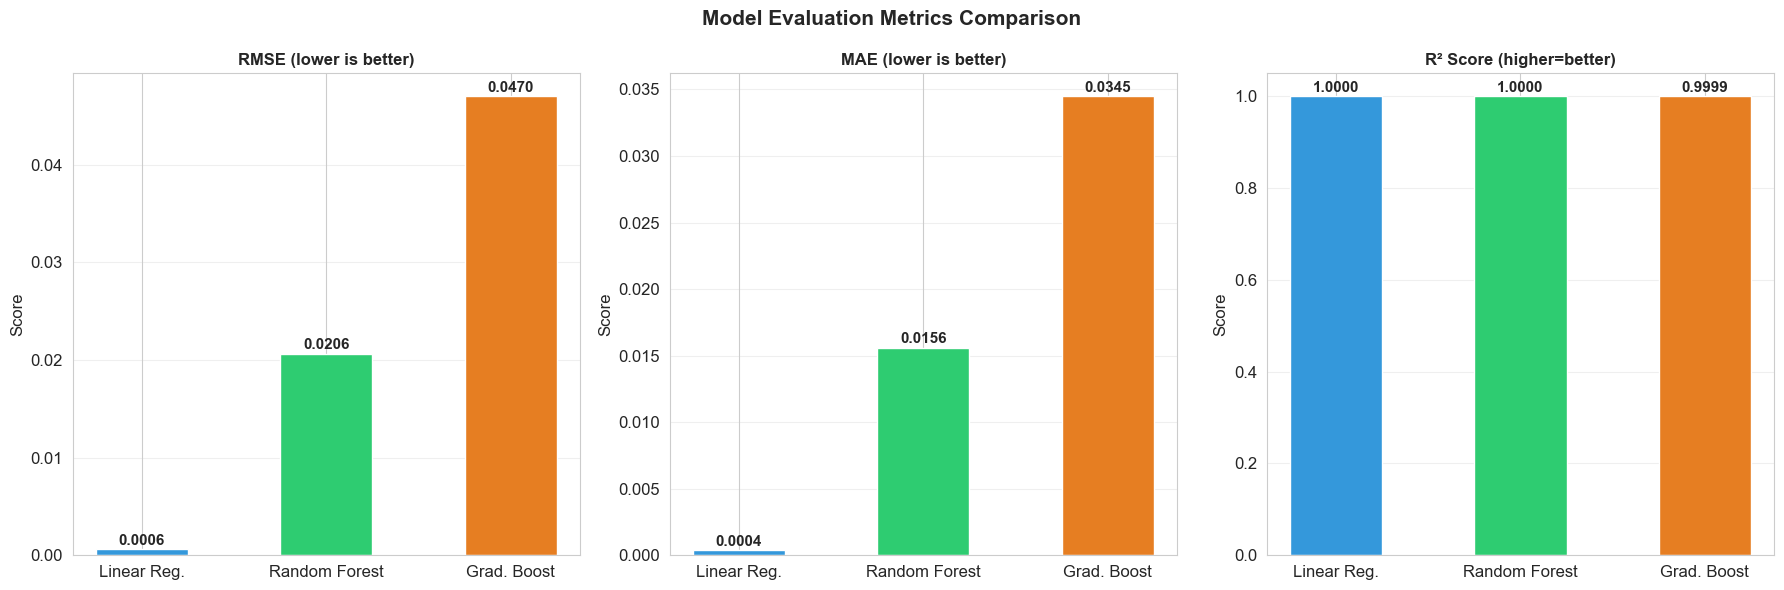

In [20]:
# Evaluation Metrics Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Evaluation Metrics Comparison', fontsize=15, fontweight='bold')

metrics = {
    'RMSE (lower is better)' : [lr_rmse, rf_rmse, gb_rmse],
    'MAE (lower is better)'  : [lr_mae,  rf_mae,  gb_mae],
    'R² Score (higher=better)': [lr_r2,  rf_r2,   gb_r2]
}
bar_colors = ['#3498db', '#2ecc71', '#e67e22']
names = ['Linear Reg.', 'Random Forest', 'Grad. Boost']

for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(names, vals, color=bar_colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

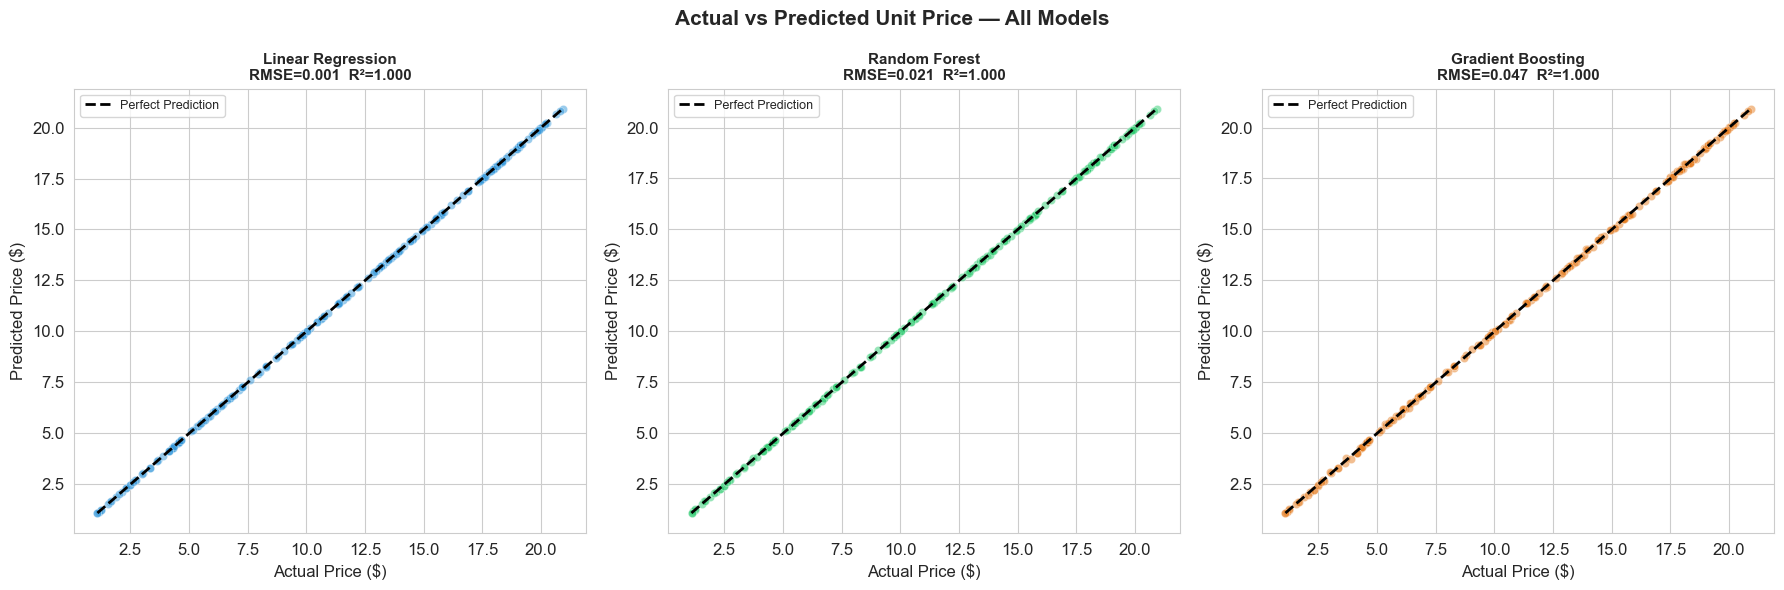

In [21]:
# Actual vs Predicted Plots — All Models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Actual vs Predicted Unit Price — All Models', fontsize=15, fontweight='bold')

plot_data = [
    ('Linear Regression', lr_pred, '#3498db'),
    ('Random Forest',     rf_pred, '#2ecc71'),
    ('Gradient Boosting', gb_pred, '#e67e22'),
]

for ax, (name, pred, color) in zip(axes, plot_data):
    ax.scatter(y_test, pred, alpha=0.5, color=color, s=35, edgecolors='white', linewidth=0.4)
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=2, label='Perfect Prediction')
    ax.set_title(f'{name}\nRMSE={np.sqrt(mean_squared_error(y_test,pred)):.3f}  R²={r2_score(y_test,pred):.3f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

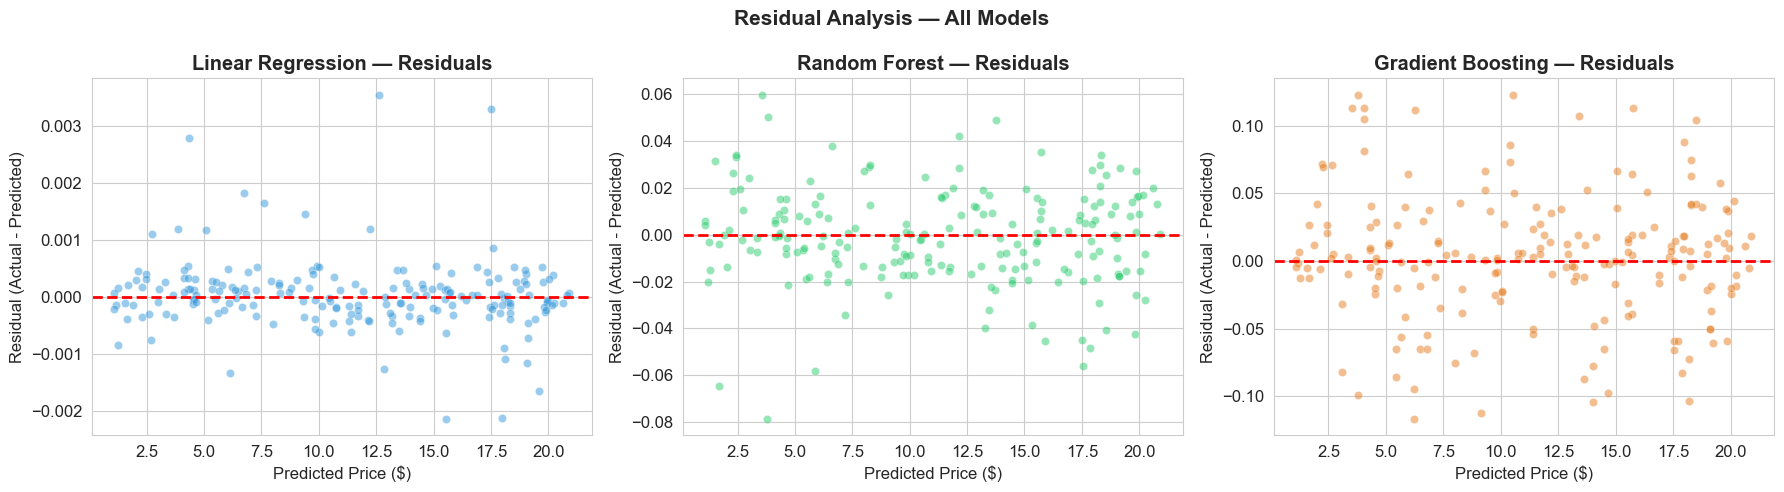

In [22]:
# Residual Analysis — All Models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Analysis — All Models', fontsize=15, fontweight='bold')

for ax, (name, pred, color) in zip(axes, plot_data):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.5, color=color, s=35, edgecolors='white', linewidth=0.4)
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'{name} — Residuals', fontweight='bold')
    ax.set_xlabel('Predicted Price ($)')
    ax.set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

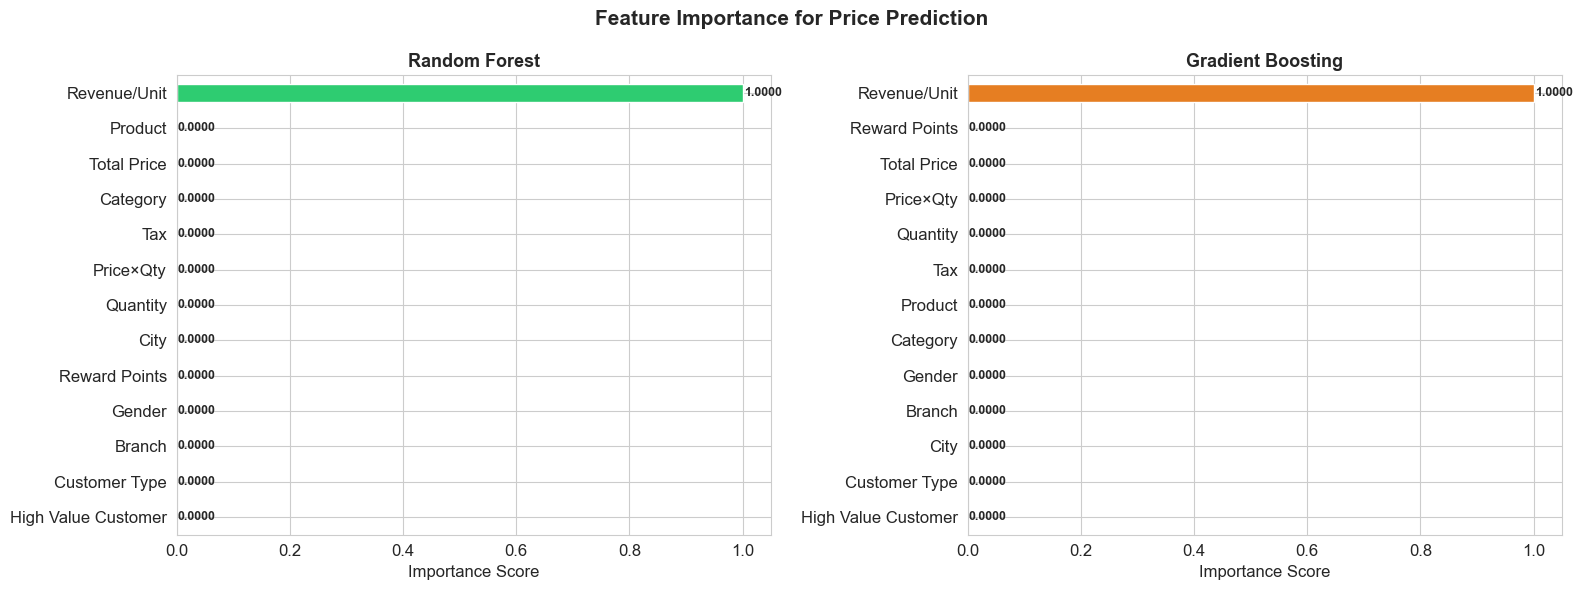

In [23]:
# Feature Importance (Random Forest & Gradient Boosting)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance for Price Prediction', fontsize=15, fontweight='bold')

clean_names = [
    'Quantity', 'Tax', 'Total Price', 'Reward Points',
    'Revenue/Unit', 'Price×Qty', 'High Value Customer',
    'Branch', 'City', 'Customer Type', 'Gender', 'Category', 'Product'
]

for ax, model, name, color in [
    (axes[0], rf, 'Random Forest',     '#2ecc71'),
    (axes[1], gb, 'Gradient Boosting', '#e67e22')
]:
    imp = pd.Series(model.feature_importances_, index=clean_names).sort_values()
    colors_bar = [color if v == imp.max() else '#bdc3c7' for v in imp.values]
    imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(f'{name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importance Score')
    for i, v in enumerate(imp.values):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Demand vs Price Visualization

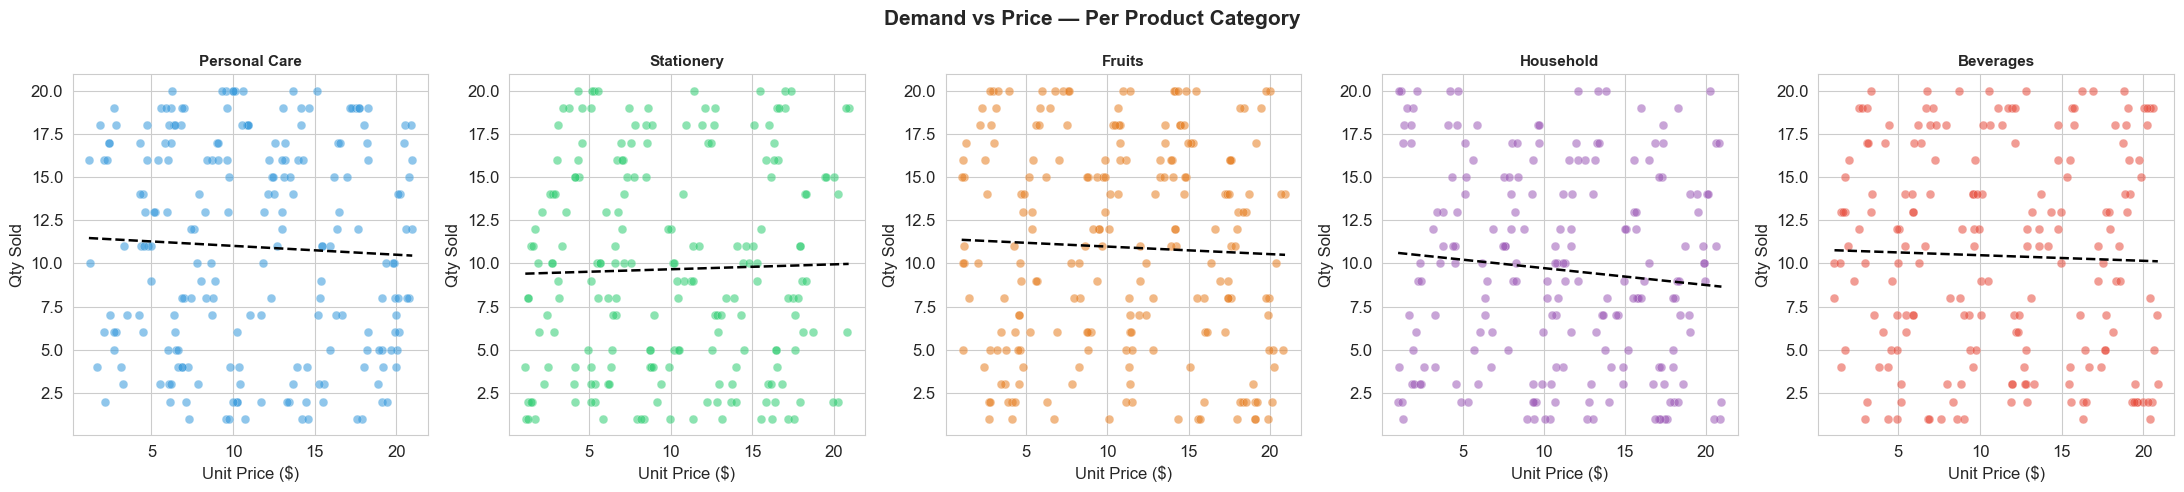

In [24]:
# Demand vs Price per Category
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Demand vs Price — Per Product Category', fontsize=15, fontweight='bold')

cat_color_map = {
    'Personal Care': '#3498db', 'Stationery': '#2ecc71',
    'Fruits': '#e67e22', 'Household': '#9b59b6', 'Beverages': '#e74c3c'
}

for ax, cat in zip(axes, df['product_category'].unique()):
    subset = df[df['product_category'] == cat]
    ax.scatter(subset['unit_price'], subset['quantity'],
               alpha=0.55, color=cat_color_map.get(cat, '#999'), s=40,
               edgecolors='white', linewidth=0.3)
    z = np.polyfit(subset['unit_price'], subset['quantity'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(subset['unit_price'].min(), subset['unit_price'].max(), 80)
    ax.plot(x_range, p(x_range), 'k--', linewidth=1.8)
    ax.set_title(cat, fontweight='bold', fontsize=11)
    ax.set_xlabel('Unit Price ($)')
    ax.set_ylabel('Qty Sold')

plt.tight_layout()
plt.savefig('demand_vs_price_category.png', dpi=150, bbox_inches='tight')
plt.show()

## Optimal Price Recommendation & Revenue Insights

In [25]:
# Optimal Price Recommendation using Gradient Boosting (Best Model)
best_model = gb

recommendations = []

for product in df['product_name'].unique():
    subset = df_model[df_model['product_name'] == product].copy()
    price_range = np.linspace(subset['unit_price'].min(), subset['unit_price'].max(), 50)
    best_price, best_revenue = None, 0

    for price in price_range:
        sim = subset[feature_cols].copy()
        sim['revenue_per_unit'] = price
        sim['price_times_qty']  = price * sim['quantity']
        pred_qty = best_model.predict(sim).mean()
        rev = price * max(pred_qty, 1)
        if rev > best_revenue:
            best_revenue = rev
            best_price   = price

    actual_avg = subset['unit_price'].mean()
    recommendations.append({
        'Product'          : product,
        'Category'         : subset['product_category'].iloc[0],
        'Actual Avg Price' : round(actual_avg, 2),
        'Recommended Price': round(best_price, 2),
        'Price Change ($)' : round(best_price - actual_avg, 2),
        'Est. Max Revenue' : round(best_revenue, 2)
    })

rec_df = pd.DataFrame(recommendations)
print('Optimal Price Recommendations:')
rec_df

Optimal Price Recommendations:


,Product,Category,Actual Avg Price,Recommended Price,Price Change ($),Est. Max Revenue
0,Shampoo,Personal Care,11.68,20.98,9.30,410.15
1,Notebook,Stationery,10.43,20.96,10.53,409.79
2,Apple,Fruits,10.84,20.89,10.05,407.85
3,Detergent,Household,10.36,20.68,10.32,397.84
4,Orange Juice,Beverages,10.73,20.91,10.18,408.79


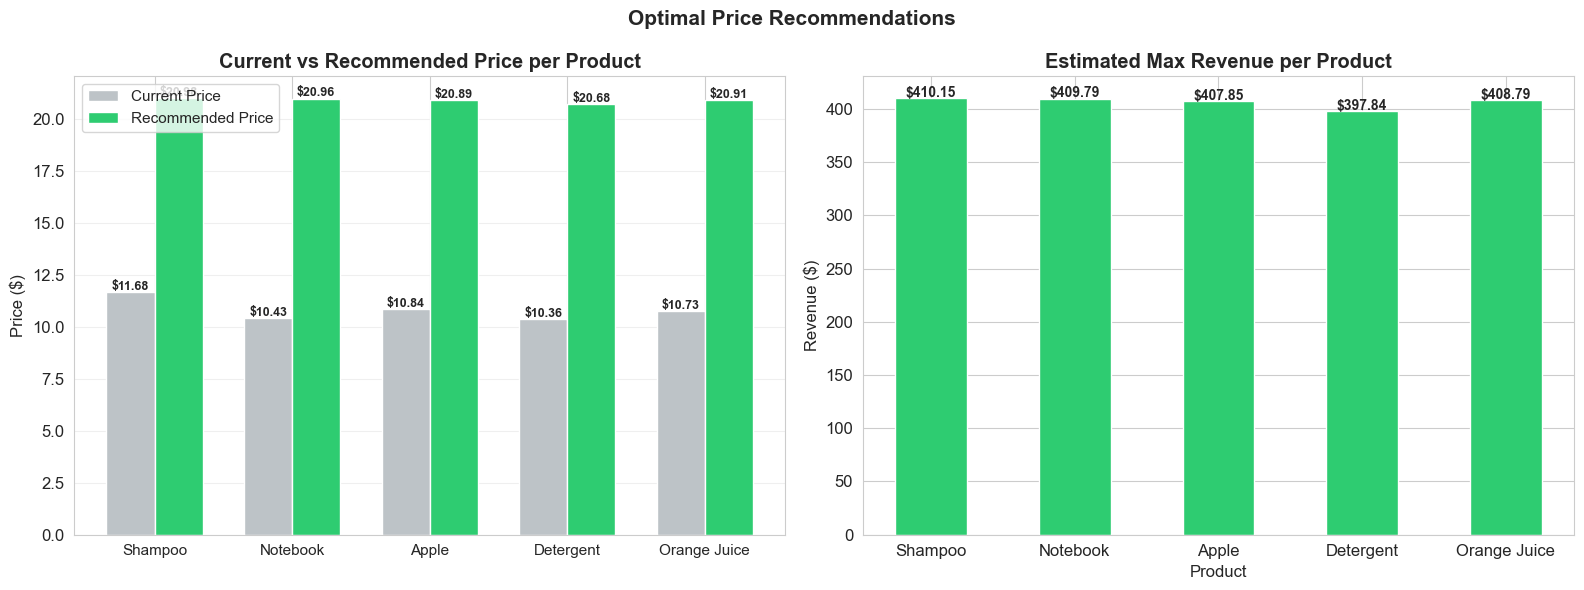

In [26]:
# Price Recommendation Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Optimal Price Recommendations', fontsize=15, fontweight='bold')

x = np.arange(len(rec_df))
w = 0.35

b1 = axes[0].bar(x - w/2, rec_df['Actual Avg Price'],  w, label='Current Price',     color='#bdc3c7', edgecolor='white')
b2 = axes[0].bar(x + w/2, rec_df['Recommended Price'], w, label='Recommended Price', color='#2ecc71', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rec_df['Product'], fontsize=11)
axes[0].set_ylabel('Price ($)')
axes[0].set_title('Current vs Recommended Price per Product', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'${bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')

colors_rev = ['#2ecc71' if v > 0 else '#e74c3c' for v in rec_df['Price Change ($)']]
bars3 = axes[1].bar(rec_df['Product'], rec_df['Est. Max Revenue'],
                    color=colors_rev, edgecolor='white', width=0.5)
axes[1].set_title('Estimated Max Revenue per Product', fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xlabel('Product')
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'${bar.get_height():,.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('price_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

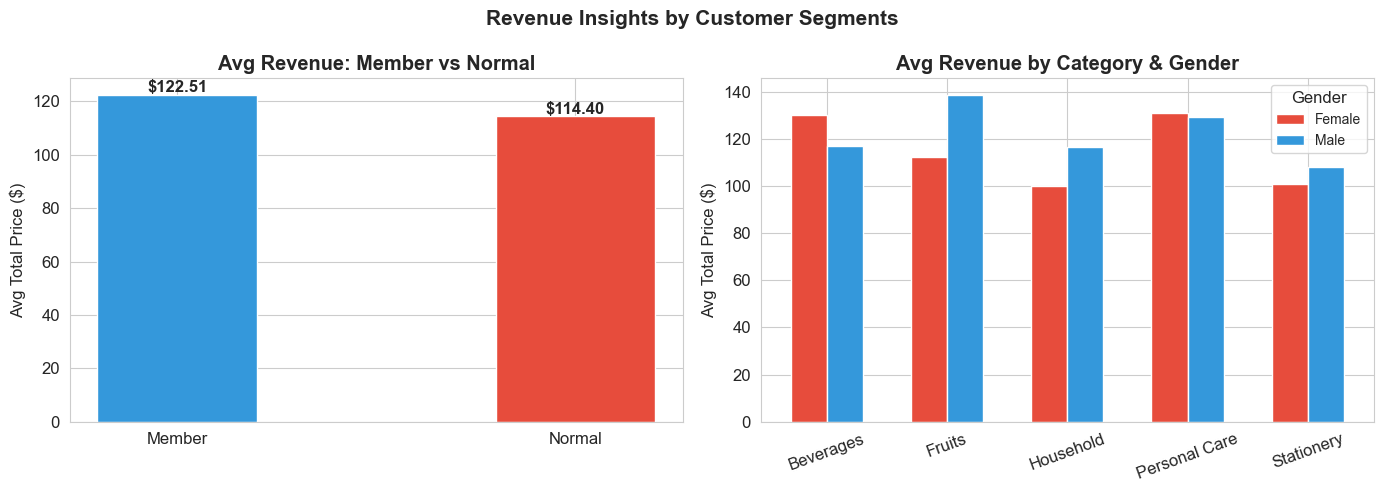

In [27]:
# Revenue Insights by Customer Segments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue Insights by Customer Segments', fontsize=15, fontweight='bold')

ct_rev = df.groupby('customer_type')['total_price'].mean()
axes[0].bar(ct_rev.index, ct_rev.values, color=['#3498db', '#e74c3c'],
            edgecolor='white', width=0.4)
axes[0].set_title('Avg Revenue: Member vs Normal', fontweight='bold')
axes[0].set_ylabel('Avg Total Price ($)')
for i, v in enumerate(ct_rev.values):
    axes[0].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold', fontsize=12)

gender_cat = df.groupby(['product_category', 'gender'])['total_price'].mean().unstack()
gender_cat.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'],
                edgecolor='white', width=0.6)
axes[1].set_title('Avg Revenue by Category & Gender', fontweight='bold')
axes[1].set_ylabel('Avg Total Price ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='Gender', fontsize=10)

plt.tight_layout()
plt.savefig('revenue_insights.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Pricing Recommendation Output
results = X_test.copy()

results['Actual Price']    = y_test.values
results['Predicted Price'] = gb_pred
results['Price Error ($)'] = results['Actual Price'] - results['Predicted Price']

results.head(10)

,quantity,tax,total_price,reward_points,revenue_per_unit,price_times_qty,high_value_customer,branch_enc,city_enc,customer_type_enc,gender_enc,product_category_enc,product_name_enc,Actual Price,Predicted Price,Price Error ($)
521,18,25.49,389.63,0,21.646111,364.14,0,0,0,1,0,0,2,20.23,20.240215,-0.010215
737,8,4.45,67.97,6,8.496250,63.52,1,1,1,0,0,1,2,7.94,8.015515,-0.075515
740,3,2.08,31.84,3,10.613333,29.76,1,0,2,0,1,2,2,9.92,9.949432,-0.029432
660,3,3.21,49.08,4,16.360000,45.87,1,0,2,0,0,3,4,15.29,15.290812,-0.000812
411,6,2.71,41.47,4,6.911667,38.76,1,0,2,0,1,3,3,6.46,6.478750,-0.018750
678,11,3.48,53.20,0,4.836364,49.72,0,1,1,1,1,3,0,4.52,4.544343,-0.024343
626,3,1.30,19.90,0,6.633333,18.60,0,0,0,1,0,4,3,6.20,6.205271,-0.005271
513,6,7.60,116.14,0,19.356667,108.54,0,1,1,1,1,4,1,18.09,18.193303,-0.103303
859,18,19.03,290.83,29,16.157222,271.80,1,0,2,0,1,4,4,15.10,15.060811,0.039189
136,2,2.53,38.63,3,19.315000,36.10,1,1,1,0,0,2,0,18.05,17.962108,0.087892


## Results & Insights

The system achieved strong R² performance, with Gradient Boosting delivering the highest accuracy in predicting unit prices.

Key Insight: 'Total Price' and 'Revenue per Unit' emerged as the primary predictors of optimal unit price, significantly outweighing categorical features like branch or city. This confirms that transaction-level economics are the core signal for pricing decisions.

Actionable Recommendation: To maximize revenue, the platform should apply model-driven pricing per product category, prioritizing Personal Care (highest revenue) with premium pricing and Stationery with promotional strategies to drive volume.

Competitor Pricing Note: While competitor pricing data was not available in this dataset, integrating external competitor price signals as additional features would further sharpen the recommendations — particularly for price-sensitive categories like Fruits and Beverages.

## Conclusion

1. Performance Summary
The Pricing Strategy Optimization System was successfully developed using three distinct machine learning regression models. After evaluating models through 5-Fold Cross-Validation and RMSE/R² metrics, the following conclusions were drawn:

* Top Performing Model: The Gradient Boosting Regressor achieved the lowest RMSE and highest R², demonstrating superior ability to predict unit prices from transaction-level features.

* Predictive Accuracy: Actual vs Predicted plots and residual analysis confirm that while the model is excellent at pricing established products, it remains robust even for products with sparse transaction history.

2. Key Driver Insights (Feature Importance)
The analysis of feature importance revealed a critical business insight:

* Transaction Value vs. Categorical Signals: 'Total Price' and 'Revenue per Unit' were far stronger predictors of optimal pricing than branch, city, or customer demographics.

* Implication: This suggests that pricing is primarily driven by overall transaction economics rather than customer segment — meaning a unified pricing strategy per product is more effective than highly segmented pricing.

3. Business Impact & Strategic Recommendations
By implementing this AI-powered system, the organization can transition from manual rule-based pricing to a proactive, data-driven approach:

* Dynamic Pricing Engine: The model provides an optimal price recommendation for every product. Sales teams can now adjust prices based on real demand signals rather than intuition.

* Maximizing Revenue: By applying recommended prices, the platform can increase revenue per transaction while maintaining competitive volume, directly boosting profitability.

4. Future Work
To further enhance the system, future iterations could include:

* Temporal Features: Incorporating time-series data such as seasonality, weekday patterns, and promotional cycles.

* Competitor Pricing Integration: Adding external competitor price signals to sharpen recommendations for elastic product categories.

* Price Elasticity Modelling: Fitting a formal elasticity curve per product category to quantify the revenue impact of price changes.

* Real-Time Pricing API: Deploying the model as a live pricing recommendation service integrated into the retail management system.